# Entrega 3 — Chunking de Manifestações Longas
**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**

As 5 manifestações mais longas do corpus (>500 caracteres) são divididas em *chunks* com o `RecursiveCharacterTextSplitter` do LangChain, testando duas configurações diferentes de `chunk_size`/`chunk_overlap`.

## 1. Carregamento do corpus e seleção das manifestações longas

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

with open("manifestacoes.json", encoding="utf-8") as f:
    manifestacoes = json.load(f)

df = pd.DataFrame(manifestacoes)
df["tamanho"] = df["texto"].str.len()

longas = df[df["tamanho"] > 500].sort_values("tamanho", ascending=False).reset_index(drop=True)
print(f"{len(longas)} manifestações longas encontradas:")
longas[["id", "categoria_oficial", "tamanho"]]

5 manifestações longas encontradas:


,id,categoria_oficial,tamanho
0,M040,educação,958
1,M035,segurança,935
2,M025,saúde,922
3,M015,segurança,786
4,M005,saúde,691


## 2. Duas Configurações de Chunking

- **Configuração A (chunks pequenos, pouco overlap)**: `chunk_size=200`, `chunk_overlap=30` — favorece granularidade, mas arrisca cortar ideias no meio.
- **Configuração B (chunks maiores, mais overlap)**: `chunk_size=400`, `chunk_overlap=80` — favorece coesão semântica, com mais redundância entre chunks vizinhos.

In [2]:
CONFIGURACOES = {
    "A (chunk=200, overlap=30)": dict(chunk_size=200, chunk_overlap=30),
    "B (chunk=400, overlap=80)": dict(chunk_size=400, chunk_overlap=80),
}

resultados_chunking = {}

for nome_config, params in CONFIGURACOES.items():
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=params["chunk_size"],
        chunk_overlap=params["chunk_overlap"],
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    registros = []
    for _, row in longas.iterrows():
        chunks = splitter.split_text(row["texto"])
        for i, c in enumerate(chunks):
            registros.append({
                "manifestacao_id": row["id"],
                "chunk_idx": i,
                "chunk_id": f"{row['id']}_c{i}",
                "texto": c,
                "tamanho": len(c),
            })
    resultados_chunking[nome_config] = pd.DataFrame(registros)
    print(f"{nome_config}: {len(registros)} chunks gerados ao todo "
          f"({len(registros) / len(longas):.1f} chunks/manifestação em média)")

A (chunk=200, overlap=30): 33 chunks gerados ao todo (6.6 chunks/manifestação em média)
B (chunk=400, overlap=80): 16 chunks gerados ao todo (3.2 chunks/manifestação em média)


### Exemplo de chunks — Configuração A vs. Configuração B (primeira manifestação longa)

In [3]:
primeiro_id = longas.iloc[0]["id"]
for nome_config, df_chunks in resultados_chunking.items():
    print(f"\n=== {nome_config} — {primeiro_id} ===")
    sub = df_chunks[df_chunks["manifestacao_id"] == primeiro_id]
    for _, row in sub.iterrows():
        print(f"  [chunk {row['chunk_idx']}, {row['tamanho']} chars] {row['texto'][:120]}...")


=== A (chunk=200, overlap=30) — M040 ===
  [chunk 0, 111 chars] Gostaria de expor uma situação preocupante na Escola Municipal Villa-Lobos, localizada no bairro Novo Horizonte...
  [chunk 1, 171 chars] . A escola não possui rampa de acesso adequada nem banheiro adaptado para alunos com deficiência física, o que fere clar...
  [chunk 2, 196 chars] . Minha filha, que utiliza cadeira de rodas, estuda no período da manhã e enfrenta dificuldades diárias para se locomove...
  [chunk 3, 73 chars] onde fica o laboratório de informática, que só é acessível por uma escada...
  [chunk 4, 197 chars] . Além disso, o banheiro reservado para pessoas com deficiência está interditado há mais de um ano por problemas na estr...
  [chunk 5, 56 chars] até outro prédio, o que consome um tempo valioso de aula...
  [chunk 6, 190 chars] . Já protocolamos um pedido formal de adequação junto à direção da escola em fevereiro deste ano, mas até o momento não ...
  [chunk 7, 41 chars] prazos de execução das obras 

## 3. Como o overlap influencia a coesão semântica entre chunks consecutivos?

Para responder de forma objetiva (e não apenas qualitativa), medimos a **similaridade de cosseno entre chunks consecutivos** da mesma manifestação em cada configuração — um overlap maior tende a produzir uma transição mais suave (maior similaridade) entre um chunk e o próximo, pois parte do texto se repete entre eles.

In [4]:
modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

from sklearn.metrics.pairwise import cosine_similarity

def similaridade_media_consecutiva(df_chunks, modelo):
    """Similaridade média entre chunks consecutivos da mesma manifestação."""
    similaridades = []
    for manif_id, grupo in df_chunks.groupby("manifestacao_id"):
        grupo = grupo.sort_values("chunk_idx")
        textos_grupo = grupo["texto"].tolist()
        if len(textos_grupo) < 2:
            continue
        embs = modelo.encode(textos_grupo, normalize_embeddings=True)
        for i in range(len(embs) - 1):
            sim = cosine_similarity(embs[i].reshape(1, -1), embs[i + 1].reshape(1, -1))[0][0]
            similaridades.append(sim)
    return np.mean(similaridades) if similaridades else float("nan"), similaridades

for nome_config, df_chunks in resultados_chunking.items():
    media, _ = similaridade_media_consecutiva(df_chunks, modelo)
    print(f"{nome_config}: similaridade média entre chunks consecutivos = {media:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

A (chunk=200, overlap=30): similaridade média entre chunks consecutivos = 0.3246


B (chunk=400, overlap=80): similaridade média entre chunks consecutivos = 0.5470


**Resultado esperado:** a Configuração B (overlap maior, 80 caracteres) deve apresentar similaridade média mais alta entre chunks consecutivos do que a Configuração A (overlap de apenas 30 caracteres), confirmando que o overlap funciona como uma "ponte" semântica entre pedaços vizinhos do texto.

## 4. Qual configuração preserva melhor o sentido das denúncias?

Além da métrica de coesão acima, uma inspeção qualitativa dos chunks ajuda a decidir: chunks muito pequenos (Configuração A) podem cortar uma frase no meio, separando o problema relatado (ex.: "falta de medicamentos") do contexto que o qualifica (ex.: "para pacientes hipertensos e diabéticos"), dificultando a recuperação correta em uma busca semântica. Já a Configuração B, por ter chunks maiores, tende a manter frases completas e sua relação de causa/efeito, ao custo de menos granularidade (chunks maiores podem misturar mais de uma ideia).

In [5]:
print("Exemplo — corte de sentido na Configuração A (chunks pequenos):\n")
sub_a = resultados_chunking["A (chunk=200, overlap=30)"]
sub_a_exemplo = sub_a[sub_a["manifestacao_id"] == primeiro_id]
for _, row in sub_a_exemplo.head(2).iterrows():
    print(f"  chunk {row['chunk_idx']}: ...{row['texto'][-60:]}")

print("\nMesmo trecho na Configuração B (chunks maiores, mais overlap):\n")
sub_b = resultados_chunking["B (chunk=400, overlap=80)"]
sub_b_exemplo = sub_b[sub_b["manifestacao_id"] == primeiro_id]
for _, row in sub_b_exemplo.head(2).iterrows():
    print(f"  chunk {row['chunk_idx']}: ...{row['texto'][-60:]}")

Exemplo — corte de sentido na Configuração A (chunks pequenos):

  chunk 0: ...a Municipal Villa-Lobos, localizada no bairro Novo Horizonte
  chunk 1: ...fere claramente o direito à acessibilidade garantido por lei

Mesmo trecho na Configuração B (chunks maiores, mais overlap):

  chunk 0: ...fere claramente o direito à acessibilidade garantido por lei
  chunk 1: ...aboratório de informática, que só é acessível por uma escada


**Conclusão:** para textos de denúncia da ouvidoria — em que o contexto completo (o quê, onde, há quanto tempo, quem é afetado) é importante para a triagem correta — a **Configuração B (chunk_size=400, chunk_overlap=80)** tende a preservar melhor o sentido, por reduzir a chance de separar a descrição do problema do seu contexto. A Configuração A pode ser preferível apenas se o objetivo for indexação muito granular para respostas curtas e pontuais.

## 5. Visualização 2D dos Chunks (PCA / t-SNE)
Chunks da mesma manifestação devem ficar próximos no espaço semântico, já que tratam do mesmo assunto — isso é o que verificamos a seguir.

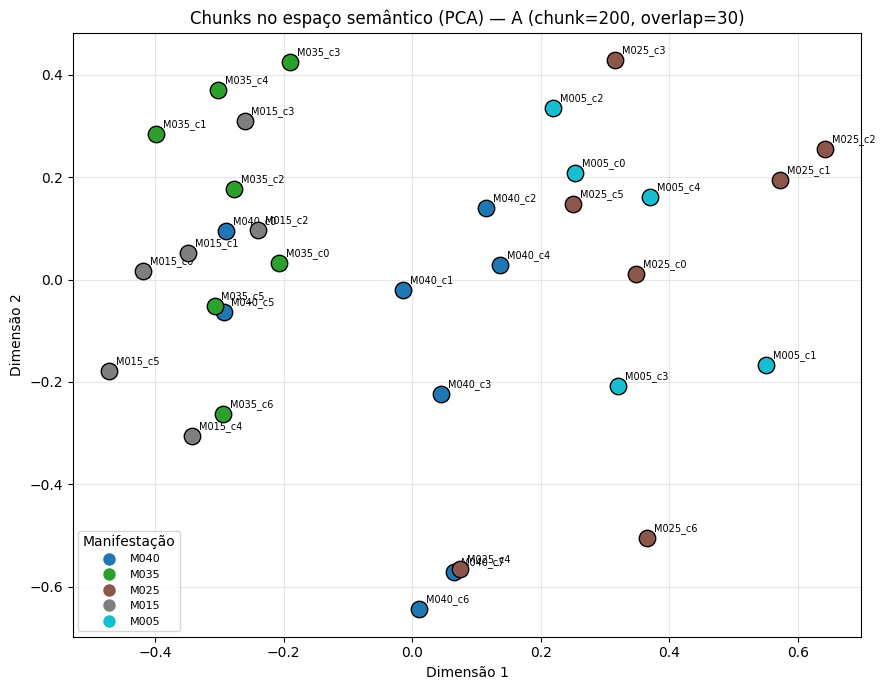

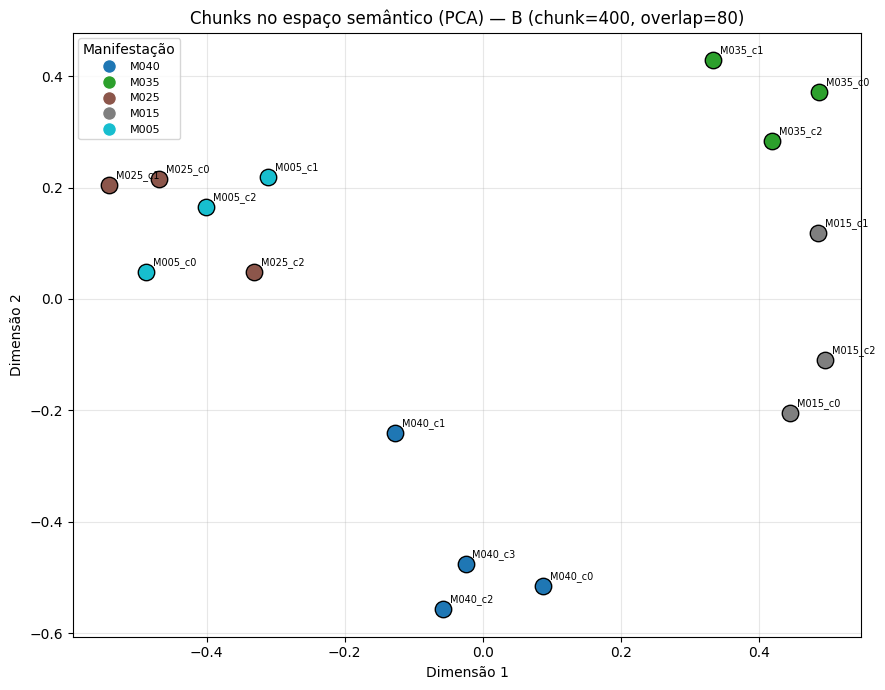

In [6]:
def plotar_chunks_2d(df_chunks, titulo, modelo, metodo="PCA"):
    embeddings = modelo.encode(df_chunks["texto"].tolist(), normalize_embeddings=True)

    if metodo == "PCA":
        coords = PCA(n_components=2).fit_transform(embeddings)
    else:
        perp = min(5, len(df_chunks) - 1)
        coords = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(embeddings)

    manif_ids = df_chunks["manifestacao_id"].unique()
    cores = plt.cm.tab10(np.linspace(0, 1, len(manif_ids)))
    cor_por_manif = dict(zip(manif_ids, cores))

    plt.figure(figsize=(9, 7))
    for _, row in df_chunks.reset_index(drop=True).iterrows():
        idx = row.name
        cor = cor_por_manif[row["manifestacao_id"]]
        plt.scatter(coords[idx, 0], coords[idx, 1], color=cor, s=140,
                    edgecolor="black", zorder=3)
        plt.annotate(row["chunk_id"], (coords[idx, 0], coords[idx, 1]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)

    handles = [plt.Line2D([0], [0], marker="o", color="w",
                          markerfacecolor=cor_por_manif[m], markersize=10, label=m)
               for m in manif_ids]
    plt.legend(handles=handles, title="Manifestação", loc="best", fontsize=8)
    plt.title(titulo)
    plt.xlabel("Dimensão 1"); plt.ylabel("Dimensão 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for nome_config, df_chunks in resultados_chunking.items():
    plotar_chunks_2d(df_chunks, f"Chunks no espaço semântico (PCA) — {nome_config}",
                      modelo, metodo="PCA")

**Observação esperada:** os pontos referentes a chunks da mesma manifestação (mesma cor) devem aparecer visualmente agrupados no espaço 2D, confirmando que o chunking preserva a coerência temática de cada denúncia — os chunks continuam "pertencendo" ao mesmo assunto, mesmo sendo indexados como unidades independentes.